<a href="https://colab.research.google.com/github/NOA11235/Assembler/blob/main/ResNet_Computer_Vision_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Noa Rosenbom, ID 330910415*

In [ ]:
#Noa Rosenbom, ID 330910415
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [28:39<00:00, 99.2kB/s]


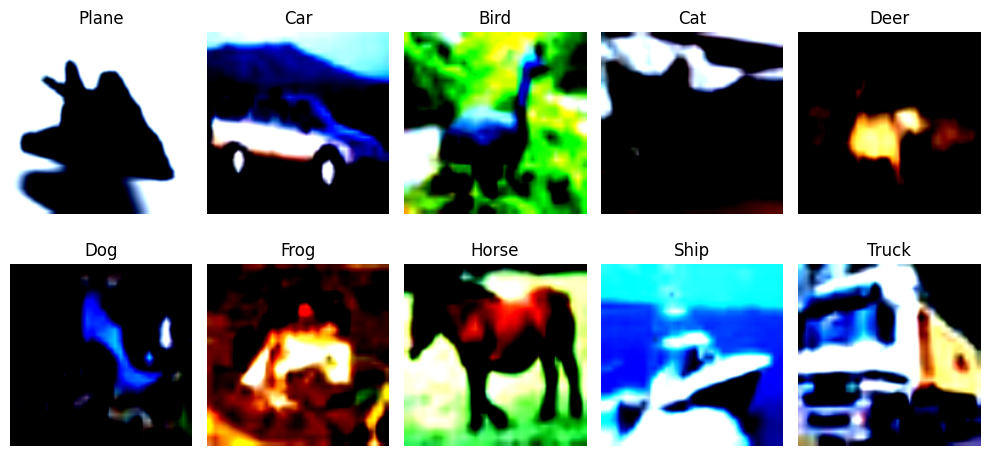

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['Plane', 'Car', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
# Dictionary to store one image per class
images_per_class = {}
# Iterate over the dataset to find one example for each label
for img, label in dataset:
    if label not in images_per_class:
        images_per_class[label] = img
    if len(images_per_class) == 10:
        break
# Create a figure for plotting
fig = plt.figure(figsize=(10, 5))

for i in range(10):
    img = images_per_class[i]
    # PyTorch images are (C, H, W), but matplotlib needs (H, W, C)
    # so we are using permute to change the order of dimensions
    img_display = img.permute(1, 2, 0).numpy()

    ax = fig.add_subplot(2, 5, i + 1)
    ax.imshow(img_display)
    ax.set_title(class_names[i])
    ax.axis('off') # Hide axis numbers

plt.tight_layout()
plt.show()

In [ ]:
import torchvision.models as models

# Load the ResNet18 model
# 'pretrained=True' downloads the weights learned on ImageNet
resnet_model = models.resnet18(pretrained=True)

# Set the model to evaluation mode (since we are not training it yet)
resnet_model.eval()



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  